![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [1]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
----------------------------------------
✓ numpy 1.26.4
✓ pandas 2.1.4
✓ matplotlib 3.8.0
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [2]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- Respuesta 1: La latencia representa el tiempo que tarda en completarse una operación o solicitud, es decir, cuánto se demora desde que se pide algo hasta que se obtiene el resultado.
- Respuesta 2: El throughput indica cuántas operaciones o datos se pueden procesar en un periodo de tiempo, o sea, qué tan rápido trabaja el sistema en conjunto.
- Respuesta 3: Porque en el acceso secuencial los datos se leen en orden, lo que reduce los saltos o interrupciones, haciendo que el sistema trabaje de forma continua y eficiente.
- Respuesta 4: Porque en el acceso aleatorio los datos están dispersos, lo que obliga al sistema a hacer más movimientos o búsquedas, aumentando el esfuerzo y el tiempo necesario.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [3]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 256

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 256
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- Respuesta 1: El archivo tiene un tamaño de 256 MB, mientras que la memoria RAM del equipo es de 8 GB. Esto significa que el archivo es mucho más pequeño que la RAM, por lo que no es suficiente para superar la caché de memoria. En consecuencia, gran parte de los datos puede mantenerse en memoria, lo que puede hacer que las mediciones sean más rápidas de lo que serían accediendo directamente al disco.
- Respuesta 2: En acceso aleatorio, esperaría que los bloques más pequeños, como 4 KB o 16 KB, tengan mejor rendimiento. Esto se debe a que en este tipo de acceso solo se necesita una pequeña parte de los datos, y leer bloques grandes implicaría traer información innecesaria, aumentando el tiempo de lectura.
- Respuesta 3: Estoy ejecutando desde mi maquina local usando anaconda Jypiter

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [ ]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [5]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

El archivo ya existe y tiene el tamaño esperado.
Tamaño final del archivo (bytes): 268435456


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- Respuesta 1: Este archivo funciona como el conjunto de datos sobre el cual se realizan las pruebas de lectura, permitiendo medir el rendimiento del sistema en diferentes condiciones como tamaños de bloque y tipos de acceso.
- Respuesta 2: Es útil porque permite simular un escenario más realista donde los datos no caben completamente en memoria, lo que ayuda a evaluar el rendimiento del disco y no solo de la RAM.
- Respuesta 3: Si el archivo fuera demasiado pequeño, el sistema operativo podría almacenarlo completamente en la caché, haciendo que las lecturas sean mucho más rápidas y no reflejen el rendimiento real del disco, sino el de la memoria.

## 5. Funciones auxiliares de medición

In [6]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [7]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 0.7797 s, throughput: 328.35 MiB/s
Aleatorio  -> tiempo: 0.0749 s, throughput: 208.50 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.2606 s, throughput: 982.23 MiB/s
Aleatorio  -> tiempo: 0.1054 s, throughput: 592.90 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.1317 s, throughput: 1944.22 MiB/s
Aleatorio  -> tiempo: 0.1897 s, throughput: 1318.15 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.1000 s, throughput: 2558.98 MiB/s
Aleatorio  -> tiempo: 0.5401 s, throughput: 1851.37 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,268435456,65536,0.779656,328.349812,4.0
1,Aleatorio,4096,16384000,4000,0.074939,208.501803,4.0
2,Secuencial,16384,268435456,16384,0.260630,982.234221,16.0
3,Aleatorio,16384,65536000,4000,0.105414,592.898122,16.0
4,Secuencial,65536,268435456,4096,0.131672,1944.223565,64.0
5,Aleatorio,65536,262144000,4000,0.189660,1318.148960,64.0
6,Secuencial,262144,268435456,1024,0.100040,2558.981521,256.0
7,Aleatorio,262144,1048576000,4000,0.540141,1851.368781,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

- Respuesta 1: En todos los tamaños de bloque (4 KB, 16 KB, 64 KB y 256 KB), el acceso secuencial fue más rápido que el acceso aleatorio. Esto se observa porque siempre tiene menor tiempo de ejecución y mayor throughput en comparación con el acceso aleatorio.
- Respuesta 2: Sí, el throughput aumentó a medida que creció el tamaño del bloque. Por ejemplo, en acceso secuencial pasó de aproximadamente 328 MiB/s (4 KB) a 2558 MiB/s (256 KB). Esto ocurre porque bloques más grandes permiten transferir más datos por operación, reduciendo la sobrecarga de acceso.
- Respuesta 3: La mayor diferencia se observa en el bloque de 256 KB. En este caso, el throughput secuencial es de 2558.98 MiB/s, mientras que el aleatorio es de 1851.37 MiB/s, lo que da una diferencia de aproximadamente 707 MiB/s. También se nota en el tiempo: secuencial tarda 0.1000 s, mientras que aleatorio tarda 0.5401 s, mostrando una diferencia significativa en rendimiento.

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [8]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado: SSD NVMe (modelo teórico simplificado)
- Latencia asumida: 10μs=1×10−5s
- Throughput asumido: 5GB/s≈5.37×109bytes/s

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

El modelo teórico no refleja completamente el comportamiento real del sistema. Aunque se trabaja con un SSD NVMe, los resultados experimentales muestran velocidades considerablemente menores a las esperadas. Esto se explica porque el modelo asume condiciones ideales, mientras que en la práctica intervienen factores como el overhead del sistema operativo (llamadas al sistema, manejo de buffers y planificación de E/S), que introducen retrasos adicionales. Además, el tamaño de bloque influye notablemente en el rendimiento: con bloques pequeños predomina la latencia y se obtienen velocidades bajas, mientras que con bloques grandes el throughput mejora significativamente. También se observa que el acceso secuencial es más eficiente que el aleatorio, ya que este último implica mayor latencia efectiva y ciertas penalizaciones internas del controlador, a pesar de no existir partes mecánicas en los SSD. Por último, las limitaciones del hardware real, como el procesador y posibles restricciones del bus o del controlador NVMe, impiden alcanzar el rendimiento máximo teórico. En conjunto, el modelo teórico resulta útil como referencia ideal y permite entender las tendencias generales, pero tiende a sobreestimar el rendimiento al no considerar las condiciones reales del sistema.

In [9]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.050010,5118.976205
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.050010,5118.976205
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.050010,5118.976205
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.050010,5118.976205
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [10]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,268435456,65536,0.779656,328.349812,4.0,0.050010,5118.976205,15.590008,0.064144
1,Aleatorio,4096,16384000,4000,0.074939,208.501803,4.0,0.043052,362.935239,1.740682,0.574488
2,Secuencial,16384,268435456,16384,0.260630,982.234221,16.0,0.050010,5118.976205,5.211564,0.191881
3,Aleatorio,16384,65536000,4000,0.105414,592.898122,16.0,0.052207,1197.156753,2.019161,0.495255
4,Secuencial,65536,268435456,4096,0.131672,1944.223565,64.0,0.050010,5118.976205,2.632915,0.379807
5,Aleatorio,65536,262144000,4000,0.189660,1318.148960,64.0,0.088828,2814.423923,2.135133,0.468355
6,Secuencial,262144,268435456,1024,0.100040,2558.981521,256.0,0.050010,5118.976205,2.000396,0.499901
7,Aleatorio,262144,1048576000,4000,0.540141,1851.368781,256.0,0.235313,4249.667995,2.295419,0.435650


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

- Pregunta 1: Los tiempos empíricos son mayores que los teóricos. La columna elapsed_ratio_empirical_vs_theoreticalmuestra valores mayores a 1 en todos los casos (por ejemplo: 15.59, 5.21, 2.63, etc.). Esto significa que, en la práctica, las ejecuciones toman más tiempo del que predice el modelo teórico.
Además, esto se confirma indirectamente con el rendimiento: La columna throughput_ratio_empirical_vs_theoreticaltiene valores menores a 1 , lo que indica menor rendimiento real.
- Pregunta 2: La teoría se aproxima mejor en los casos donde la relación está más cercana a 1. En tiempos (elapsed) : el valor más cercano a 1 es aproximadamente 1.74 , aunque sigue siendo una desviación considerable. En rendimiento: hay valores como 0.57, 0.49, 0.49 , que están relativamente más cerca de 1 comparados con los de tiempo.
- Pregunta 3: Las diferencias entre el modelo teórico y el práctico pueden explicarse por varios factores del entorno real:

Caché del sistema operativo:El uso de caché puede acelerar o alterar los accesos a discoteca, haciendo que los tiempos reales no sigan el modelo ideal.
Carga del sistema (CPU en uso): Aunque el sistema tiene un 8.07% en reposo, pueden existir procesos en el segundo plano que afecten el rendimiento.
Tipo de disco (SSD NVMe):Aunque es rápido, su comportamiento real depende de controladores, colas de E/S y concurrencia, lo que no siempre está modelado teóricamente.
Limitaciones del CPU (Celeron N4020, 2 núcleos): Es un procesador de gama baja, lo que puede generar cuellos de botella en operaciones intensivas.
Temperatura y estrangulamiento térmico:
Si el equipo se calienta, puede reducir automáticamente su rendimiento.

## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [11]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\Sofi\Desktop\UdeA\SEMESTRE6\ESTRUCTURADEDATOSYLAB\lab3-IO_performance-SofiaEspinal\images


Guardada: fig_throughput.png


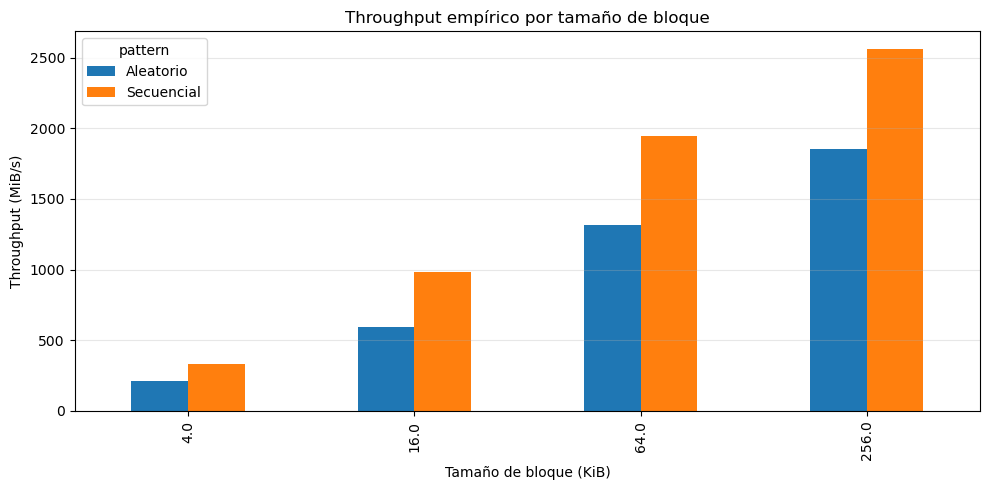

In [12]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

- Pregunta 1: Las barras del patrón secuencial (color naranja) son más altas en todos los tamaños de bloque (4 KiB, 16 KiB, 64 KiB y 256 KiB) en comparación con las del patrón aleatorio (color azul).
- Pregunta 2: Que las barras sean más altas indica un mayor rendimiento (MiB/s) , es decir: El patrón secuencial tiene mejor rendimiento que el aleatorio y se pueden leer/escribir más datos por segundo cuando el acceso es secuencial. Por ejemplo: para un bloque de 256 KiB , el rendimiento secuencial es de aproximadamente 2550 MiB/s , mientras que el aleatorio se acerca a 1850 MiB/s .
- Pregunta 3: El patrón secuencial aprovecha mejor la lectura en bloques. A medida que aumenta el tamaño del bloque, el rendimiento crece significativamente en ambos casos, pero el incremento es mayor en el acceso secuencial.

Guardada: fig_tiempo_empirico.png


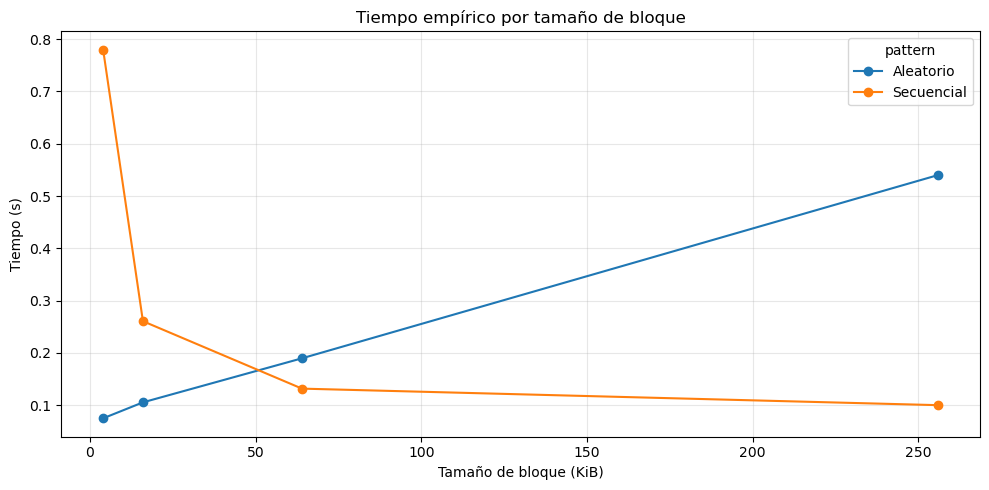

In [13]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

El tiempo total presenta comportamientos opuestos según el patrón de acceso: en el caso secuencial , el tiempo disminuye significativamente a medida que aumenta el tamaño del bloque, pasando de aproximadamente 0,78 s en 4 KiB a cerca de 0,10 s en 256 KiB, lo que indica un uso más eficiente de bloques grandes; en contraste, en el acceso aleatorio , el tiempo aumenta conforme crece el tamaño del bloque, desde alrededor de 0.07 s hasta unos 0.54 s, evidenciando un mayor costo al manejar bloques grandes en este patrón. Ambas curvas divergen progresivamente, pero la mayor diferencia se observa en 256 KiB , donde el acceso secuencial es mucho más rápido que el aleatorio, lo que demuestra que el tamaño de bloque beneficia ampliamente al acceso secuencial mientras perjudica al aleatorio.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


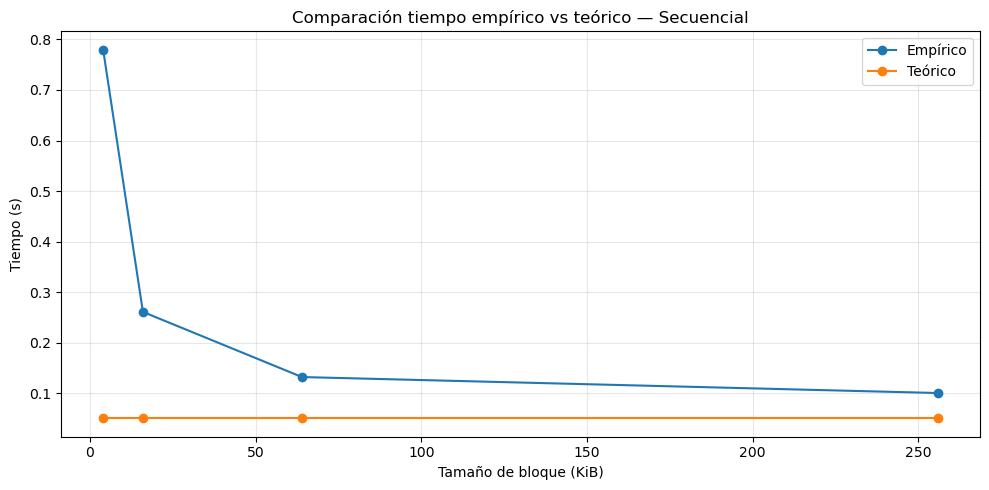

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


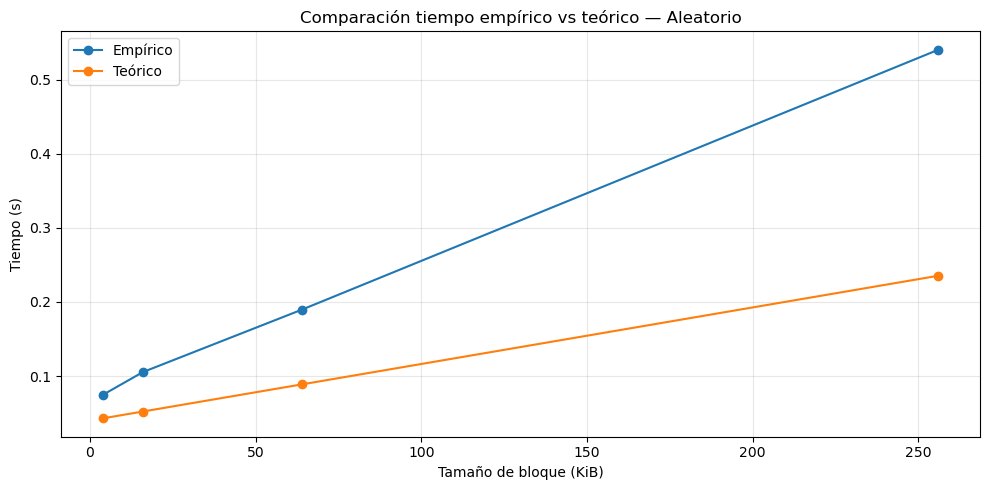

In [14]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

- Pregunta 1: No del todo. En el caso secuencial , el comportamiento es bastante diferente: mientras el tiempo real baja cuando aumentan los bloques, el modelo teórico prácticamente no cambia, como si asumiera que todo cuesta lo mismo. En cambio, en el acceso aleatorio sí se parece más, porque ambos tiempos van subiendo a medida que crece el tamaño del bloque, aunque no coinciden exactamente.
- Pregunta 2: La mayor diferencia se nota claramente en el acceso secuencial con bloques pequeños (4 KiB) . Ahí el tiempo real es mucho más alto de lo que predice la teoría. También hay una separación importante en el acceso aleatorio con bloques grandes (256 KiB), donde otra vez el tiempo real se dispara más que el teórico.
- Pregunta 3: Esto deja ver que el modelo teórico se queda corto y subestima el tiempo real . Es como si asumiera un escenario ideal que no pasa en la práctica. Probablemente no está teniendo en cuenta cosas muy reales como la carga del sistema, el uso de caché, las latencias del disco o incluso las limitaciones del hardware, que al final terminarán haciendo que todo tarde más de lo esperado.

Guardada: fig_speedup.png


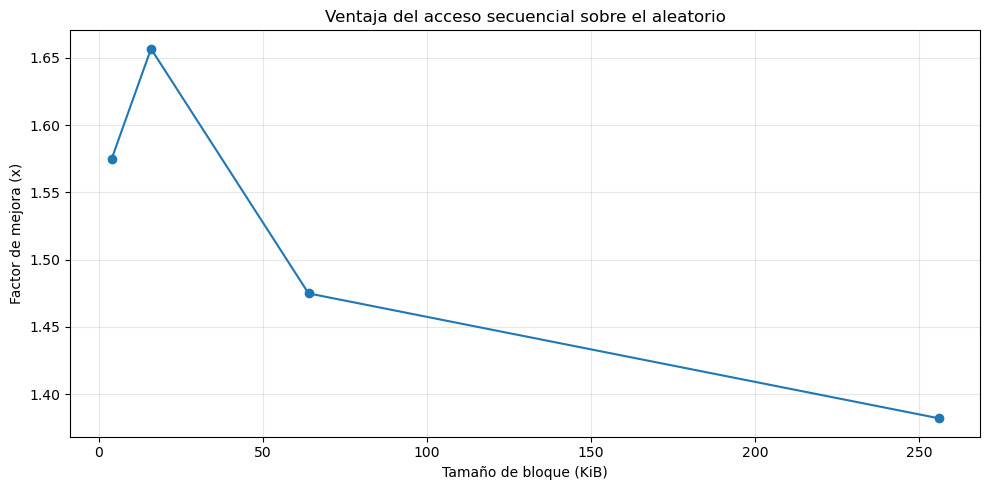

In [15]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

- Pregunta 1: El mayor factor de mejora fue de aproximadamente 1.66 veces, y se presentó cuando el tamaño de bloque era de 16 KB. Esto significa que, en ese caso, el acceso secuencial fue casi el doble de rápido que el acceso aleatorio, lo cual es una diferencia bastante notable en rendimiento.

- Pregunta 2: La ventaja del acceso secuencial no se mantiene constante: primero aumenta (de 4 KB a 16 KB), donde alcanza su punto máximo, y luego empieza a disminuir a medida que el tamaño del bloque crece. Por ejemplo, en bloques grandes como 256 KB, la diferencia baja a alrededor de 1.38 veces, lo que muestra que aunque el acceso secuencial sigue siendo mejor, la diferencia ya no es tan marcada.

- Pregunta 3: Esto sugiere que, al diseñar software, es buena idea organizar los datos y procesos para que el acceso sea lo más secuencial posible, especialmente cuando se trabaja con bloques pequeños o medianos, ya que ahí se obtiene mayor beneficio. Sin embargo, cuando se usan bloques grandes, la diferencia entre secuencial y aleatorio se reduce, por lo que la optimización sigue siendo útil, pero no tan crítica como en otros casos

## 10. Resumen automático de resultados

In [16]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,0.779656,0.074939,328.349812,208.501803,1.574806
1,16.0,0.260630,0.105414,982.234221,592.898122,1.656666
2,64.0,0.131672,0.189660,1944.223565,1318.148960,1.474965
3,256.0,0.100040,0.540141,2558.981521,1851.368781,1.382211


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

En este experimento se pudo entender que la información en disco se almacena en bloques, y que la forma en que estos bloques se leen afecta directamente el rendimiento del sistema. Esto es importante porque el sistema operativo y el hardware están optimizados para acceder a datos de manera continua, no dispersa. Por esta razón, el acceso secuencial y el aleatorio tienen desempeños tan distintos, incluso en un SSD, ya que el acceso aleatorio implica saltos entre ubicaciones que reducen la eficiencia de lectura. Los resultados lo confirmaron claramente: por ejemplo, con bloques de 256 KB se alcanzó un throughput secuencial de 2558.98 MiB/s, mientras que el aleatorio fue de 1851.37 MiB/s, mostrando una diferencia significativa. Además, el modelo teórico predijo correctamente la tendencia general, indicando que el acceso secuencial sería más eficiente y que el tamaño de bloque influiría en el rendimiento, lo cual se evidenció en las mediciones. Sin embargo, también se observó que la diferencia disminuye con bloques más grandes, algo que el modelo simplificado no siempre refleja con precisión. Con base en estos resultados, en un sistema real tomaría la decisión de diseñar estructuras de datos y procesos que favorezcan accesos secuenciales, especialmente en operaciones intensivas de lectura, para aprovechar mejor el rendimiento del hardware.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.